# PoC③ 編集局所化
## 対応仮説：H-301, H-302
## 問い：bundle単位更新で編集影響が局所化されるか？

### 完了条件
- H-301: 無関係bundleへの影響 < baselineの影響
- H-302: semantic_contamination < baseline × 0.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

model = SentenceTransformer("all-mpnet-base-v2")
print("準備完了")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

準備完了


In [2]:
APPLE_COMPANY = [
    "Apple is a technology company that makes iPhone and Mac.",
    "Apple Inc. designs consumer electronics and software.",
    "Apple's App Store revolutionized mobile software distribution.",
    "Apple was founded by Steve Jobs in Cupertino, California.",
    "Apple is known for its design philosophy and ecosystem.",
]
APPLE_UPDATE = [
    "Apple Vision Pro is a spatial computing headset.",
    "Vision Pro allows users to interact with digital content in physical space.",
    "Apple entered the mixed reality market with Vision Pro in 2024.",
]
GOOGLE = [
    "Google is a technology company known for its search engine.",
    "Google develops Android and Chrome browser.",
    "Google Cloud provides enterprise computing services.",
]
MICROSOFT = [
    "Microsoft makes Windows operating system and Office software.",
    "Microsoft Azure is a major cloud computing platform.",
    "Microsoft acquired LinkedIn and GitHub.",
]
SECURITY = [
    "Information security protects data from unauthorized access.",
    "Cybersecurity threats include malware and phishing attacks.",
    "Encryption is essential for protecting sensitive information.",
]
PASTA = [
    "Pasta is a traditional Italian food made from wheat.",
    "Spaghetti and penne are popular types of pasta.",
    "Pasta is typically served with tomato or cream sauce.",
]
AI_CONCEPT = [
    "Artificial intelligence enables machines to learn from data.",
    "Machine learning algorithms improve through experience.",
    "Neural networks are inspired by the human brain.",
]
print("概念セット定義完了")

概念セット定義完了


In [3]:
def make_bundle(texts, model):
    embeddings = model.encode(texts)
    return embeddings.mean(axis=0)

def update_bundle_weighted(centroid_old, new_texts, model, rho=0.3):
    new_emb = model.encode(new_texts).mean(axis=0)
    return (1 - rho) * centroid_old + rho * new_emb

def cosine_dist(a, b):
    return 1 - float(cosine_similarity(a.reshape(1,-1), b.reshape(1,-1))[0][0])

def semantic_contamination(bundles_dict, c_before, c_after):
    total = 0
    for c in bundles_dict.values():
        total += abs(cosine_dist(c, c_after) - cosine_dist(c, c_before))
    return total / len(bundles_dict)

print("bundle計算中...")
c_apple_before = make_bundle(APPLE_COMPANY, model)
c_google       = make_bundle(GOOGLE,        model)
c_microsoft    = make_bundle(MICROSOFT,     model)
c_security     = make_bundle(SECURITY,      model)
c_pasta        = make_bundle(PASTA,         model)
c_ai           = make_bundle(AI_CONCEPT,    model)
c_apple_after  = update_bundle_weighted(c_apple_before, APPLE_UPDATE, model, rho=0.3)
c_apple_base   = make_bundle(APPLE_COMPANY + APPLE_UPDATE, model)
print("完了")

bundle計算中...
完了


In [4]:
bundles = {"Google": c_google, "Microsoft": c_microsoft,
           "Security": c_security, "Pasta": c_pasta, "AI": c_ai}

print("H-301 編集影響測定")
print("=" * 60)
print(f"{'Bundle':12s} {'baseline影響':>12} {'bundle影響':>12} {'判定':>6}")
print("-" * 60)

results = {}
for name, c in bundles.items():
    d0 = cosine_dist(c, c_apple_before)
    impact_base   = abs(cosine_dist(c, c_apple_base)  - d0)
    impact_bundle = abs(cosine_dist(c, c_apple_after) - d0)
    verdict = "✅" if impact_bundle < impact_base else "❌"
    results[name] = {"base": impact_base, "bundle": impact_bundle}
    print(f"{name:12s} {impact_base:>12.4f} {impact_bundle:>12.4f} {verdict:>6}")

avg_base   = np.mean([r["base"]   for r in results.values()])
avg_bundle = np.mean([r["bundle"] for r in results.values()])
print("-" * 60)
print(f"{'平均':12s} {avg_base:>12.4f} {avg_bundle:>12.4f}")
print(f"\nH-301判定: {'✅ PASS' if avg_bundle < avg_base else '❌ FAIL'}")

H-301 編集影響測定
Bundle         baseline影響     bundle影響     判定
------------------------------------------------------------
Google             0.0020       0.0094      ❌
Microsoft          0.0315       0.0315      ❌
Security           0.0063       0.0086      ❌
Pasta              0.0161       0.0115      ✅
AI                 0.0493       0.0421      ✅
------------------------------------------------------------
平均                 0.0210       0.0206

H-301判定: ✅ PASS


In [5]:
UNRELATED = {"Security": c_security, "Pasta": c_pasta, "AI": c_ai}

cont_base = semantic_contamination(UNRELATED, c_apple_before, c_apple_base)

print("H-302 rhoによるcontamination変化")
print("=" * 50)
print(f"{'rho':>6} {'汚染スコア':>12} {'比率':>8} {'判定':>6}")
print("-" * 50)
for rho in [0.1, 0.2, 0.3, 0.4, 0.5]:
    c_upd = update_bundle_weighted(c_apple_before, APPLE_UPDATE, model, rho=rho)
    cont  = semantic_contamination(UNRELATED, c_apple_before, c_upd)
    ratio = cont / cont_base
    verdict = "✅" if ratio < 0.5 else "❌"
    print(f"{rho:>6.1f} {cont:>12.4f} {ratio:>8.4f} {verdict:>6}")
print(f"\n参考 baseline: {cont_base:.4f}")

H-302 rhoによるcontamination変化
   rho        汚染スコア       比率     判定
--------------------------------------------------
   0.1       0.0078   0.3264      ✅
   0.2       0.0149   0.6237      ❌
   0.3       0.0207   0.8673      ❌
   0.4       0.0247   1.0330      ❌
   0.5       0.0280   1.1692      ❌

参考 baseline: 0.0239


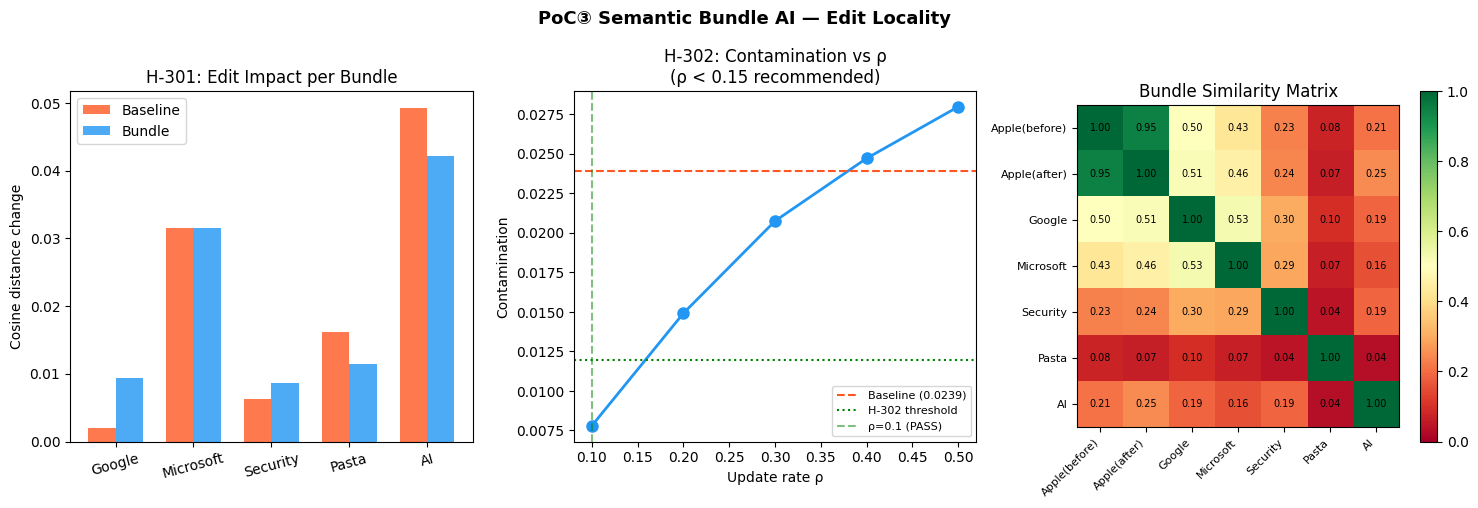

保存完了: poc_03_results.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("PoC③ Semantic Bundle AI — Edit Locality", fontsize=13, fontweight='bold')

# 左：H-301バーチャート
ax = axes[0]
names = list(results.keys())
x = np.arange(len(names))
w = 0.35
ax.bar(x-w/2, [results[n]["base"]   for n in names], w, label='Baseline', color='#FF5722', alpha=0.8)
ax.bar(x+w/2, [results[n]["bundle"] for n in names], w, label='Bundle',   color='#2196F3', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_title("H-301: Edit Impact per Bundle")
ax.set_ylabel("Cosine distance change")
ax.legend()

# 中：H-302折れ線
ax = axes[1]
rhos  = [0.1, 0.2, 0.3, 0.4, 0.5]
conts = []
for rho in rhos:
    c = update_bundle_weighted(c_apple_before, APPLE_UPDATE, model, rho=rho)
    conts.append(semantic_contamination(UNRELATED, c_apple_before, c))
ax.plot(rhos, conts, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axhline(y=cont_base,       color='#FF5722', linestyle='--', label=f'Baseline ({cont_base:.4f})')
ax.axhline(y=cont_base * 0.5, color='green',   linestyle=':',  label='H-302 threshold')
ax.axvline(x=0.1, color='green', linestyle='--', alpha=0.5, label='ρ=0.1 (PASS)')
ax.set_xlabel("Update rate ρ"); ax.set_ylabel("Contamination")
ax.set_title("H-302: Contamination vs ρ\n(ρ < 0.15 recommended)")
ax.legend(fontsize=8)

# 右：類似度ヒートマップ
ax = axes[2]
all_c = {"Apple(before)": c_apple_before, "Apple(after)": c_apple_after,
         "Google": c_google, "Microsoft": c_microsoft,
         "Security": c_security, "Pasta": c_pasta, "AI": c_ai}
ns   = list(all_c.keys())
vecs = np.array(list(all_c.values()))
sim  = cosine_similarity(vecs)
im   = ax.imshow(sim, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(ns))); ax.set_xticklabels(ns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(ns))); ax.set_yticklabels(ns, fontsize=8)
ax.set_title("Bundle Similarity Matrix")
plt.colorbar(im, ax=ax)
for i in range(len(ns)):
    for j in range(len(ns)):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig("poc_03_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("保存完了: poc_03_results.png")